# Smart School Project — Prédiction des échecs étudiants
Exploration des données (EDA) et comparaison de modèles de régression pour prédire le `score_examen`.

## Imports

Les bibliothèques utilisées dans ce projet :

| Bibliothèque | Rôle |
|---|---|
| **numpy / pandas** | Manipulation de données et calculs numériques |
| **matplotlib / seaborn** | Visualisation graphique |
| **scipy** | Calculs statistiques — KDE (*Kernel Density Estimation* : estimation de densité par noyau) |
| **sklearn** (*scikit-learn*) | Outils ML : modèles, encodeurs, évaluation, pipelines |
| **xgboost** | Implémentation optimisée du Gradient Boosting |

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import issparse
from scipy.stats import gaussian_kde
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn import set_config
from xgboost import XGBRegressor

## Constantes et paramètres

- **PALETTE** : liste de couleurs cohérente réutilisée dans tous les graphes du notebook.
- **MI_SAMPLE_SIZE** : taille limite pour le calcul de la *Mutual Information* (MI). L'algorithme est en O(n·log n) — limiter à 50 000 lignes donne des résultats quasi-identiques en ~10× moins de temps sur 600 000 lignes.
- **small_dataset** : mettre `True` pour charger uniquement 10 000 lignes et tester rapidement le code.

In [3]:
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3']
MI_SAMPLE_SIZE = 50_000

small_dataset = False  # Mettre True pour tester sur 10 000 lignes seulement

set_config(transform_output="pandas")

## 1.a Chargement des données

Le dataset contient **630 000 étudiants** et **14 features** décrivant leurs habitudes (heures d'étude, sommeil, fête...) et leur contexte scolaire (diplôme, méthode d'étude, qualité de l'établissement...).

**Variable cible** : `score_examen` (valeur continue de 0 à 100). Un score < 50 est considéré comme un **échec**.

**Features retirées avant modélisation** :
- `id` : identifiant arbitraire, aucune information prédictive.
- `taille_etudiant` : non pertinent pour la performance académique.

In [4]:
if small_dataset:
    df = pd.read_csv('student_dataset/student_failure/train.csv', nrows=10000)
else:
    df = pd.read_csv('student_dataset/student_failure/train.csv')

df.head(10)

,id,age,genre,diplôme,heures_etude,assiduité_classe,accès_internet,heures_sommeil,qualité_sommeil,méthode_etude,évaluation_établissement,difficulté_examen,score_examen,heures_fête,taille_etudiant
0,0,21,male,Computer Science,7.91,98.8,NaN,4.9,average,online videos,low,easy,75.02,5,1.91
1,1,18,female,Law,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,49.03,4,1.89
2,2,20,female,Computer Science,4.68,92.6,NaN,5.8,poor,coaching,high,moderate,100.00,4,1.72
3,3,19,male,Computer Science,2.00,49.5,yes,8.3,average,group study,high,moderate,63.90,4,1.51
4,4,23,female,Business Management,7.65,86.9,yes,9.6,good,self-study,high,easy,100.00,2,1.94
5,5,24,male,Marketing,5.04,85.1,yes,9.4,average,online videos,medium,moderate,70.10,5,1.71
6,6,20,male,Computer Science,4.28,87.0,no,9.1,average,mixed,high,moderate,59.58,2,1.77
7,7,22,female,Bachelor of Arts,4.19,44.9,yes,8.8,good,self-study,high,hard,78.70,5,1.69
8,8,22,female,Marketing,1.06,98.3,yes,5.0,poor,mixed,low,moderate,49.68,3,1.74
9,9,18,male,Business Administration,3.44,80.9,yes,6.2,good,group study,medium,easy,58.20,5,1.84


## 1.b Analyse des données
| Features | Type de donnée | Importance (estimation) |
| :--- | :---: | :---: |
| **id** | Numérique (N) | Inutile (X) |
| **age** | Numérique (N) | Probablement inutile (F) | 
| **genre** | Catégoriel (C) | **Utile (A)** |
| **diplôme** | Catégoriel (C) | **Utile (A)** | 
| **heures_etude** | Numérique (N) | **Utile (A)** | 
| **assiduité_classe** | Numérique (N) | **Utile (A)** |
| **accès_internet** | Catégoriel (C) | **Utile (A)** |
| **heures_sommeil** | Numérique (N) | **Utile (A)** |
| **qualité_sommeil** | Ordinal (S) | **Utile (A)** |
| **méthode_etude** | Catégoriel (C) | **Utile (A)** |
| **évaluation_établissement** | Ordinal (S) | **Utile (A)** |
| **difficulté_examen** | Ordinal (S) | **Utile (A)** |
| **score_examen** | Numérique (N) | **Cible (P)** |
| **heures_fête** | Numérique (N) | **Utile (A)** |
| **taille_etudiant** | Numérique (N) | Probablement inutile (F) |

---

### **Légende des codes**
*   **Importance :** **X** (Inutile), **F** (Faible/Probablement inutile), **A** (Utile/Apport), **P** (Prédiction/Cible).
*   **Types :** **N** (Nombre/Numérique), **C** (Catégorie nominale), **S** (Catégorie ordinale/Séquentielle).

## 2. Préparation des données — Split train / validation / test

Les données sont divisées en **3 ensembles distincts** :

| Ensemble | Proportion | Rôle |
|---|---|---|
| **Train** | 60 % | Entraîner les modèles |
| **Validation** | 20 % | Comparer les modèles et régler l'*early stopping* |
| **Test** | 20 % | Évaluation finale — jamais touché pendant l'entraînement |

> **Pourquoi 3 ensembles ?** Utiliser le même ensemble pour entraîner et évaluer le modèle introduit un biais optimiste appelé ***data leakage*** (fuite de données). Le test set garantit une mesure honnête des performances sur des données inédites.

`X_train_orig` conserve les données brutes avant encodage — nécessaire pour le calcul de la corrélation (Graphe 4) et la Mutual Information (Graphe 5).

In [5]:
y = df['score_examen']
X = df.drop(['score_examen', 'id', 'taille_etudiant'], axis=1)

# Split 3-voies : 60 % train / 20 % validation / 20 % test
# X_test est gardé strictement pour l'évaluation finale (jamais touché pendant l'entraînement)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=0  # 0.25 × 0.80 = 0.20
)
print(f'Train  : {X_train.shape}  ({len(X_train)/len(X):.0%})')
print(f'Val    : {X_valid.shape}  ({len(X_valid)/len(X):.0%})')
print(f'Test   : {X_test.shape}   ({len(X_test)/len(X):.0%})')

X_train_orig = X_train.copy()
X_test_orig  = X_test.copy()

Train  : (378000, 12)  (60%)
Val    : (126000, 12)  (20%)
Test   : (126000, 12)   (20%)


## 3. Encodage des variables catégorielles

Les modèles de ML n'acceptent que des **valeurs numériques**. Les variables textuelles doivent être converties selon leur nature :

| Type de variable | Stratégie | Variables concernées | Explication |
|---|---|---|---|
| **Ordinale** | `OrdinalEncoder` | `qualité_sommeil`, `évaluation_établissement`, `difficulté_examen` | La variable a un **ordre naturel** (ex : poor < average < good). L'ordre est défini manuellement pour que le modèle le respecte. |
| **Nominale** | `OneHotEncoder` (OHE) | `genre`, `diplôme`, `accès_internet`, `méthode_etude` | Pas d'ordre entre les modalités → chaque modalité devient une **colonne binaire** (0 ou 1). |

Le `ColumnTransformer` applique chaque encodeur sur les colonnes spécifiées et transmet les colonnes numériques inchangées (`remainder='passthrough'`).

> Changer `method` pour tester différentes stratégies et observer leur impact sur le MAE.

| method | MAE full dataset (XGBoost : val & test) |
| :--- | :---: |
| `drop_categorical` | 8.7168 & 8.6389 |
| `ordinal_encoding_random` | 7.2465 & 7.2304 |
| `ordinal_encoding_smart` | 7.2461 & 7.2274 |
| `one_hot_encoding_1` | 7.2448 & 7.2231 |
| `one_hot_encoding_2` | 7.2410 & 7.2208 |
| `ordinal_and_one_hot_encoding` | 7.2407 & 7.2230 |

In [6]:
method = 'ordinal_and_one_hot_encoding'

if method == 'drop_categorical':
    X_train = X_train.select_dtypes(exclude=['object'])
    X_valid = X_valid.select_dtypes(exclude=['object'])
    X_test  = X_test.select_dtypes(exclude=['object'])

elif method == 'ordinal_encoding_random':
    obj_mask = X_train.dtypes == 'object'
    object_cols = list(obj_mask[obj_mask].index)
    ordinal_encoder = OrdinalEncoder()
    X_train[object_cols] = ordinal_encoder.fit_transform(X_train[object_cols])
    X_valid[object_cols] = ordinal_encoder.transform(X_valid[object_cols])
    X_test[object_cols]  = ordinal_encoder.transform(X_test[object_cols])

elif method == 'ordinal_encoding_smart':
    manual_encoder = OrdinalEncoder(categories=[
        ['poor', 'average', 'good'],
        ['low',  'medium',  'high'],
        ['easy', 'moderate', 'hard']
    ])
    auto_encoder = OrdinalEncoder(categories='auto')
    preprocessor = ColumnTransformer(transformers=[
        ('ord_manuel', manual_encoder,
         ['qualité_sommeil', 'évaluation_établissement', 'difficulté_examen']),
        ('ord_auto',   auto_encoder,
         ['genre', 'diplôme', 'accès_internet', 'méthode_etude'])
    ], remainder='passthrough')
    X_train = preprocessor.fit_transform(X_train)
    X_valid = preprocessor.transform(X_valid)
    X_test  = preprocessor.transform(X_test)

elif method == 'one_hot_encoding_1':
    X_train = pd.get_dummies(X_train)
    X_valid = pd.get_dummies(X_valid)
    X_test  = pd.get_dummies(X_test)
    X_train, X_valid = X_train.align(X_valid, join='left', axis=1)
    X_train, X_test  = X_train.align(X_test,  join='left', axis=1)

elif method == 'one_hot_encoding_2':
    obj_mask = X_train.dtypes == 'object'
    object_cols = list(obj_mask[obj_mask].index)
    one_hot_encoder = OneHotEncoder(sparse_output=False)
    preprocessor = ColumnTransformer(
        transformers=[('onehot', one_hot_encoder, object_cols)],
        remainder='passthrough'
    )
    X_train = preprocessor.fit_transform(X_train)
    X_valid = preprocessor.transform(X_valid)
    X_test  = preprocessor.transform(X_test)

elif method == 'ordinal_and_one_hot_encoding':
    manual_ordinal_cols = ['qualité_sommeil', 'évaluation_établissement', 'difficulté_examen']
    one_hot_cols        = ['genre', 'diplôme', 'accès_internet', 'méthode_etude']
    ordinal_encoder = OrdinalEncoder(categories=[
        ['poor', 'average', 'good'],
        ['low',  'medium',  'high'],
        ['easy', 'moderate', 'hard']
    ])
    one_hot_encoder = OneHotEncoder(sparse_output=False)
    preprocessor = ColumnTransformer(transformers=[
        ('ordinal', ordinal_encoder, manual_ordinal_cols),
        ('onehot',  one_hot_encoder, one_hot_cols)
    ], remainder='passthrough')
    X_train = preprocessor.fit_transform(X_train)
    X_valid = preprocessor.transform(X_valid)
    X_test  = preprocessor.transform(X_test)

else:
    raise ValueError("Méthode d'encodage inconnue.")

print('Shape après preprocessing — train:', X_train.shape, '  val:', X_valid.shape, '  test:', X_test.shape)

Shape après preprocessing — train: (378000, 26)   val: (126000, 26)   test: (126000, 26)


### Conversion dense et imputation des valeurs manquantes

**Conversion dense** : certains encodeurs (ex. `OneHotEncoder`) produisent des matrices *creuses* (*sparse matrices*) pour économiser la mémoire — la plupart des cases valent 0 et ne sont pas stockées. La plupart des modèles sklearn nécessitent une matrice dense classique → `.toarray()` effectue cette conversion.

**Imputation** : les colonnes numériques transmises telles quelles (`remainder='passthrough'`) peuvent contenir des `NaN`. Le `SimpleImputer` remplace chaque valeur manquante par la **médiane** de la colonne.
- La médiane est préférée à la moyenne car elle est **robuste aux valeurs aberrantes** (*outliers*).
- Le `SimpleImputer` est *fit* uniquement sur `X_train` pour éviter toute **fuite d'information** (*data leakage*) vers `X_valid` et `X_test`.

In [7]:
X_train_dense = X_train.toarray() if issparse(X_train) else np.array(X_train)
X_valid_dense = X_valid.toarray() if issparse(X_valid) else np.array(X_valid)
X_test_dense  = X_test.toarray()  if issparse(X_test)  else np.array(X_test)

imputer = SimpleImputer(strategy='median')  # 'median' est une stratégie d'imputation qui remplace les valeurs manquantes par la valeur médiane de la colonne
X_train_dense = imputer.fit_transform(X_train_dense)
X_valid_dense = imputer.transform(X_valid_dense)
X_test_dense  = imputer.transform(X_test_dense)

## 4. Entraînement des modèles

**Tâche** : régression — prédire `score_examen` (valeur continue).

**Métrique d'évaluation** : **MAE** (*Mean Absolute Error* — Erreur Absolue Moyenne). Le MAE mesure l'écart moyen entre la prédiction et la valeur réelle, exprimé dans la même unité que le score (points). Plus il est bas, meilleur est le modèle.

Quatre modèles sont comparés à une **baseline** (modèle naïf de référence) :

| Modèle | Type | Caractéristique principale |
|---|---|---|
| Baseline | Naïf | Prédit toujours la moyenne du train set, sans regarder les features |
| Régression Linéaire | Linéaire | Suppose une relation linéaire entre les features et la cible |
| Random Forest | Ensemble (bagging) | Agrège plusieurs arbres de décision indépendants |
| XGBoost | Ensemble (boosting) | Entraîne des arbres séquentiellement pour corriger les erreurs |
| MLP | Réseau de neurones | Perceptron multi-couches — modèle de *Deep Learning* |

### Baseline — modèle de référence naïf

La **baseline** est le modèle le plus simple possible : elle prédit **toujours la même valeur** (la moyenne des scores du train set), sans regarder aucune feature.

Tout modèle entraîné doit **obligatoirement faire mieux** que cette baseline pour apporter une valeur réelle. C'est le "pire cas raisonnable".

In [8]:
baseline_pred = np.full(len(y_valid), y_train.mean())
mae_baseline  = mean_absolute_error(baseline_pred, y_valid)
print(f'Baseline (moyenne)         MAE : {mae_baseline:.4f}')

Baseline (moyenne)         MAE : 15.6232


### Régression Linéaire

La **régression linéaire** modélise la relation entre les features et la variable cible comme une **combinaison linéaire pondérée** :

`score = w₁×heures_etude + w₂×assiduité + ... + b`

Les poids `w` sont ajustés pour minimiser l'erreur sur le train set. C'est le modèle de référence linéaire — simple et interprétable, mais incapable de capturer des relations non-linéaires.

In [9]:
lr = LinearRegression()
lr.fit(X_train_dense, y_train)
mae_lr = mean_absolute_error(lr.predict(X_valid_dense), y_valid)
print(f'Régression linéaire        MAE : {mae_lr:.4f}')

Régression linéaire        MAE : 7.3502


### Random Forest (Forêt Aléatoire)

Un **Random Forest** entraîne de nombreux **arbres de décision** indépendants sur des sous-échantillons aléatoires des données (*bagging*), puis fait la **moyenne** de leurs prédictions.

- Capture les **relations non-linéaires** sans nécessiter de normalisation des features.
- `n_estimators=50` : nombre d'arbres — réduit ici pour accélérer l'entraînement (valeur habituelle : 100–200).
- `n_jobs=4` : utilise 4 cœurs CPU en parallèle.

In [10]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=4)
rf.fit(X_train_dense, y_train)
mae_rf = mean_absolute_error(rf.predict(X_valid_dense), y_valid)
print(f'Random Forest              MAE : {mae_rf:.4f}')

Random Forest              MAE : 7.5187


### XGBoost — Gradient Boosting

**XGBoost** (*eXtreme Gradient Boosting*) entraîne des arbres **séquentiellement** : chaque nouvel arbre corrige les erreurs résiduelles du précédent (*boosting*).

Paramètres clés :
- `n_estimators=1000` : nombre maximum de rounds — l'*early stopping* arrêtera avant si nécessaire.
- `learning_rate=0.05` : pas d'apprentissage — plus faible = apprentissage plus lent mais plus précis.
- `early_stopping_rounds=50` : arrête si le **RMSE** sur le validation set ne s'améliore pas pendant 50 rounds consécutifs → évite le sur-apprentissage (*overfitting*).
- `eval_set` : ensemble utilisé pour surveiller les performances à chaque round.

In [11]:
model_xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    n_jobs=4,
    early_stopping_rounds=50,
    eval_metric='rmse'
)
model_xgb.fit(
    X_train_dense, y_train,
    eval_set=[(X_valid_dense, y_valid)],
    verbose=False
)
mae_xgb = mean_absolute_error(model_xgb.predict(X_valid_dense), y_valid)
print(f'XGBoost                    MAE : {mae_xgb:.4f}')

XGBoost                    MAE : 7.2407


### MLP — Réseau de neurones (*Deep Learning*)

Un **MLP** (*Multi-Layer Perceptron* — Perceptron multi-couches) est un réseau de neurones entièrement connecté. Architecture utilisée : 2 couches cachées de 128 puis 64 neurones, avec activation **ReLU** (*Rectified Linear Unit* — unité linéaire rectifiée : `f(x) = max(0, x)`).

> ⚠️ Les réseaux de neurones sont **très sensibles à l'échelle des features**. Un `StandardScaler` est appliqué avant l'entraînement : il centre chaque feature (moyenne = 0) et la réduit (écart-type = 1). Il est *fit* uniquement sur `X_train` pour éviter toute fuite de données.

- `early_stopping=True` : arrête si la *validation loss* ne s'améliore plus.
- `n_iter_no_change=20` : nombre d'itérations sans amélioration avant l'arrêt automatique.

In [12]:
scaler_mlp = StandardScaler()
X_train_scaled = scaler_mlp.fit_transform(X_train_dense)
X_valid_scaled = scaler_mlp.transform(X_valid_dense)

mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=300,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20
)
mlp.fit(X_train_scaled, y_train)
mae_mlp = mean_absolute_error(mlp.predict(X_valid_scaled), y_valid)
print(f'MLP (réseau de neurones)   MAE : {mae_mlp:.4f}')

MLP (réseau de neurones)   MAE : 7.3710


## 4b. Évaluation finale sur le test set et Cross-Validation (5-fold)

### Test set
Le **test set** (20 % des données, jamais vu pendant l'entraînement) est utilisé **une seule fois** à la fin pour mesurer les performances réelles de chaque modèle sur des données inédites.

### Cross-Validation (CV) k-fold
La **validation croisée** divise les données en `k` parties (*folds*) égales. Le modèle est entraîné `k` fois : à chaque itération, un fold différent sert de validation et les `k-1` autres servent d'entraînement. Ici `k=5`.

```
Fold 1 : [VAL][TRN][TRN][TRN][TRN]
Fold 2 : [TRN][VAL][TRN][TRN][TRN]
...
Fold 5 : [TRN][TRN][TRN][TRN][VAL]
```

Le MAE final = **moyenne des 5 MAE ± écart-type** (mesure de la stabilité du modèle).

> **Pourquoi un `Pipeline` ?** Un `Pipeline` sklearn enchaîne préprocesseur → imputation → modèle en un seul objet. Cela garantit que l'encodage et l'imputation sont *fit* uniquement sur les données d'entraînement de chaque fold — **aucune fuite de données** (*data leakage*) entre les folds.

> **Pourquoi un échantillon ?** Le dataset complet (378 000 lignes train) rendrait la CV trop longue. Un échantillon **stratifié** de 60 000 lignes (proportions échec/réussite conservées) donne des résultats représentatifs en temps raisonnable.

In [13]:
# --- Évaluation sur le test set (évaluation finale, modèles déjà entraînés) ---
X_test_scaled = scaler_mlp.transform(X_test_dense)

mae_test_baseline = mean_absolute_error(np.full(len(y_test), y_train.mean()), y_test)
mae_test_lr       = mean_absolute_error(lr.predict(X_test_dense),  y_test)
mae_test_rf       = mean_absolute_error(rf.predict(X_test_dense),  y_test)
mae_test_xgb      = mean_absolute_error(model_xgb.predict(X_test_dense), y_test)
mae_test_mlp      = mean_absolute_error(mlp.predict(X_test_scaled), y_test)

print('=== MAE sur le TEST SET (évaluation finale) ===')
for name, val_mae, test_mae in [
    ('Baseline (moyenne)',       mae_baseline, mae_test_baseline),
    ('Régression linéaire',      mae_lr,       mae_test_lr),
    ('Random Forest',            mae_rf,       mae_test_rf),
    ('XGBoost',                  mae_xgb,      mae_test_xgb),
    ('MLP (réseau de neurones)', mae_mlp,      mae_test_mlp),
]:
    print(f'{name:<28}  Val: {val_mae:.4f}  |  Test: {test_mae:.4f}')

=== MAE sur le TEST SET (évaluation finale) ===
Baseline (moyenne)            Val: 15.6232  |  Test: 15.5901
Régression linéaire           Val: 7.3502  |  Test: 7.3294
Random Forest                 Val: 7.5187  |  Test: 7.4945
XGBoost                       Val: 7.2407  |  Test: 7.2230
MLP (réseau de neurones)      Val: 7.3710  |  Test: 7.3473


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold

CV_SAMPLE_SIZE = 60_000  # Échantillon stratifié : dataset trop grand (504 K lignes) pour une CV complète

# Échantillonnage stratifié sur pass/fail pour conserver les proportions
_, X_cv, _, y_cv = train_test_split(
    X_train_orig.reset_index(drop=True),
    y_train.reset_index(drop=True),
    test_size=CV_SAMPLE_SIZE / len(y_train),
    stratify=(y_train.reset_index(drop=True) < 50).astype(int),
    random_state=42
)
X_cv = X_cv.reset_index(drop=True)
y_cv = y_cv.reset_index(drop=True)
print(f'Échantillon CV : {len(X_cv):,} lignes — '
      f'{(y_cv < 50).sum():,} échecs / {(y_cv >= 50).sum():,} réussites')

def make_preprocessor():
    """Retourne un ColumnTransformer non entraîné pour une utilisation dans un Pipeline CV."""
    return ColumnTransformer(transformers=[
        ('ordinal', OrdinalEncoder(categories=[
            ['poor', 'average', 'good'],
            ['low',  'medium',  'high'],
            ['easy', 'moderate', 'hard']
        ]), ['qualité_sommeil', 'évaluation_établissement', 'difficulté_examen']),
        ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'),
         ['genre', 'diplôme', 'accès_internet', 'méthode_etude'])
    ], remainder='passthrough')

cv_pipelines = {
    'Régression Linéaire': Pipeline([
        ('pre', make_preprocessor()),
        ('imp', SimpleImputer(strategy='median')),
        ('model', LinearRegression())
    ]),
    'Random Forest': Pipeline([
        ('pre', make_preprocessor()),
        ('imp', SimpleImputer(strategy='median')),
        ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=4))
    ]),
    'XGBoost': Pipeline([
        ('pre', make_preprocessor()),
        ('imp', SimpleImputer(strategy='median')),
        ('model', XGBRegressor(n_estimators=1000, learning_rate=0.05,
                               n_jobs=4, random_state=42, eval_metric='rmse'))
    ]),
    'MLP': Pipeline([
        ('pre', make_preprocessor()),
        ('imp', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', MLPRegressor(hidden_layer_sizes=(128, 64), activation='relu',
                               max_iter=300, random_state=42,
                               early_stopping=True, validation_fraction=0.1,
                               n_iter_no_change=20))
    ]),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = {}

# Baseline (calculé manuellement fold par fold)
baseline_cv = []
for tr_idx, vl_idx in kf.split(X_cv):
    pred = np.full(len(vl_idx), y_cv.iloc[tr_idx].mean())
    baseline_cv.append(mean_absolute_error(y_cv.iloc[vl_idx], pred))
cv_scores['Baseline (moyenne)'] = baseline_cv
print(f"{'Baseline (moyenne)':<22}  CV MAE : {np.mean(baseline_cv):.4f} ± {np.std(baseline_cv):.4f}")

for name, pipeline in cv_pipelines.items():
    print(f'Calcul CV — {name}...', end=' ', flush=True)
    scores = -cross_val_score(pipeline, X_cv, y_cv,
                              cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)
    cv_scores[name] = list(scores)
    print(f'CV MAE : {scores.mean():.4f} ± {scores.std():.4f}')

Échantillon CV : 60,000 lignes — 15,347 échecs / 44,653 réussites
Baseline (moyenne)      CV MAE : 15.6111 ± 0.0668
Calcul CV — Régression Linéaire... CV MAE : 7.3086 ± 0.0422
Calcul CV — Random Forest... CV MAE : 7.5745 ± 0.0480
Calcul CV — XGBoost... CV MAE : 7.3628 ± 0.0434
Calcul CV — MLP... CV MAE : 7.4230 ± 0.0486


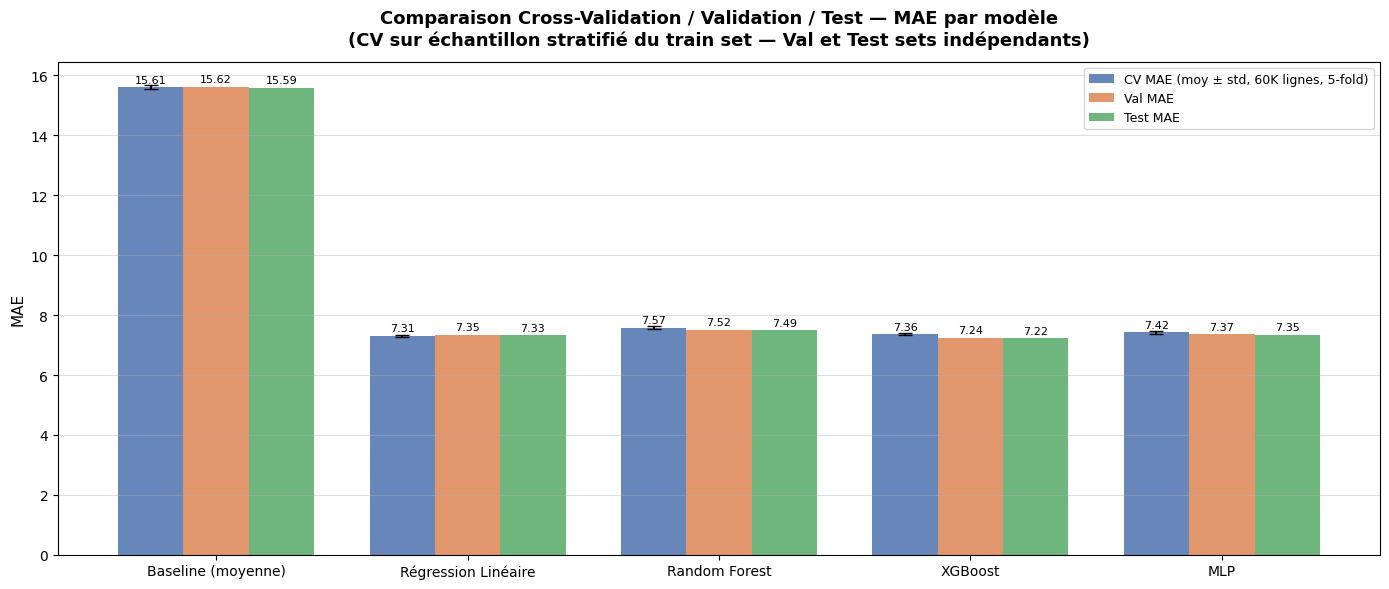


              Modèle CV MAE (moy) CV MAE (std) Val MAE Test MAE
 Baseline (moyenne)      15.6111       0.0668 15.6232  15.5901
Régression Linéaire       7.3086       0.0422  7.3502   7.3294
      Random Forest       7.5745       0.0480  7.5187   7.4945
            XGBoost       7.3628       0.0434  7.2407   7.2230
                MLP       7.4230       0.0486  7.3710   7.3473


In [15]:
# Graphe récapitulatif : CV MAE (avec barres d'erreur) + Val MAE + Test MAE
mae_val_map  = {
    'Baseline (moyenne)':  mae_baseline,
    'Régression Linéaire': mae_lr,
    'Random Forest':       mae_rf,
    'XGBoost':             mae_xgb,
    'MLP':                 mae_mlp,
}
mae_test_map = {
    'Baseline (moyenne)':  mae_test_baseline,
    'Régression Linéaire': mae_test_lr,
    'Random Forest':       mae_test_rf,
    'XGBoost':             mae_test_xgb,
    'MLP':                 mae_test_mlp,
}

names_order = list(cv_scores.keys())
cv_means = [np.mean(cv_scores[n]) for n in names_order]
cv_stds  = [np.std(cv_scores[n])  for n in names_order]
val_maes = [mae_val_map[n]         for n in names_order]
test_maes= [mae_test_map[n]        for n in names_order]

x = np.arange(len(names_order))
w = 0.26

fig_cv, ax_cv = plt.subplots(figsize=(14, 6))
b1 = ax_cv.bar(x - w, cv_means, w, yerr=cv_stds, capsize=5,
               label=f'CV MAE (moy ± std, {CV_SAMPLE_SIZE//1000}K lignes, 5-fold)',
               color=PALETTE[0], alpha=0.85)
b2 = ax_cv.bar(x,     val_maes,  w, label='Val MAE',  color=PALETTE[1], alpha=0.85)
b3 = ax_cv.bar(x + w, test_maes, w, label='Test MAE', color=PALETTE[2], alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax_cv.text(bar.get_x() + bar.get_width() / 2, h + 0.08,
                   f'{h:.2f}', ha='center', va='bottom', fontsize=8)

ax_cv.set_xticks(x)
ax_cv.set_xticklabels(names_order, fontsize=10)
ax_cv.set_ylabel('MAE', fontsize=11)
ax_cv.set_title(
    'Comparaison Cross-Validation / Validation / Test — MAE par modèle\n'
    '(CV sur échantillon stratifié du train set — Val et Test sets indépendants)',
    fontsize=13, fontweight='bold', pad=12
)
ax_cv.legend(fontsize=9)
ax_cv.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

# Tableau récapitulatif
summary = pd.DataFrame({
    'Modèle':        names_order,
    'CV MAE (moy)':  [f'{np.mean(cv_scores[n]):.4f}' for n in names_order],
    'CV MAE (std)':  [f'{np.std(cv_scores[n]):.4f}'  for n in names_order],
    'Val MAE':       [f'{mae_val_map[n]:.4f}'          for n in names_order],
    'Test MAE':      [f'{mae_test_map[n]:.4f}'         for n in names_order],
})
print('\n', summary.to_string(index=False))

## 5. Analyse Exploratoire des Données (EDA — *Exploratory Data Analysis*)

L'**EDA** vise à comprendre la structure et les patterns du dataset **avant** de modéliser. Elle permet d'identifier :
- les **valeurs manquantes** à imputer (Graphe 1)
- la **distribution** de la variable cible et les anomalies (Graphe 2)
- l'impact des **variables catégorielles** sur le score (Graphe 3)
- les **corrélations** entre variables (Graphe 4)
- les **features les plus informatives** pour prédire l'échec (Graphes 5 et 8)

Les noms de features (`feat_names_base`) sont extraits du `ColumnTransformer` via `get_feature_names_out()` et nettoyés (suppression du préfixe `encodeur__`).

In [16]:
sns.set_theme(style='whitegrid')

try:
    raw_names = preprocessor.get_feature_names_out()
    feat_names_base = [n.split('__', 1)[-1] for n in raw_names]
except Exception:
    feat_names_base = [f'feature_{i}' for i in range(X_train_dense.shape[1])]

### Graphe 1 — Valeurs manquantes par colonne

Identifie quelles colonnes contiennent des `NaN` (*Not a Number* — valeur manquante) et nécessitent une imputation avant l'entraînement. Des valeurs manquantes non traitées provoqueraient des erreurs dans la plupart des modèles sklearn.

Le pourcentage affiché au-dessus de chaque barre indique la proportion de lignes affectées.

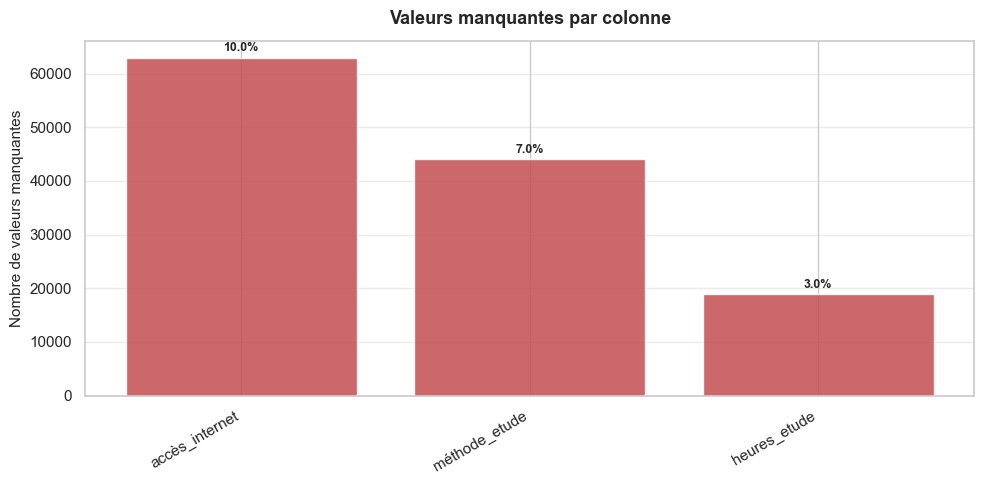

In [17]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

fig0, ax0 = plt.subplots(figsize=(10, 5))
if missing.empty:
    ax0.text(0.5, 0.5, 'Aucune valeur manquante dans le dataset',
             ha='center', va='center', fontsize=14, color='green',
             transform=ax0.transAxes)
else:
    bars0 = ax0.bar(missing.index, missing.values, color=PALETTE[3], alpha=0.85)
    for bar, val in zip(bars0, missing.values):
        ax0.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + missing.max() * 0.01,
                 f'{val / len(df):.1%}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax0.set_ylabel('Nombre de valeurs manquantes', fontsize=11)
    plt.xticks(rotation=30, ha='right')

ax0.set_title('Valeurs manquantes par colonne', fontsize=13, fontweight='bold', pad=12)
ax0.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

### Graphe 2 — Distribution des scores d'examen (variable cible)

Visualise la forme globale de la distribution de `score_examen` et met en évidence trois éléments importants :

- **Zone d'échec** (score < 50, rouge) : proportion d'étudiants qui échouent — seuil d'intervention de l'école.
- **Anomalie score = 19** (rose) : pic anormalement élevé, inexpliqué — probablement des étudiants absents ou en abandon. Ces valeurs perturbent la distribution réelle.
- **Plafonnement score = 100** (orange) : concentration artificielle au score maximum (*ceiling effect* — effet plafond).

La courbe **KDE** (*Kernel Density Estimation* — estimation de densité par noyau) lisse la distribution en excluant les anomalies (19 et 100) pour révéler la forme sous-jacente de la distribution réelle.

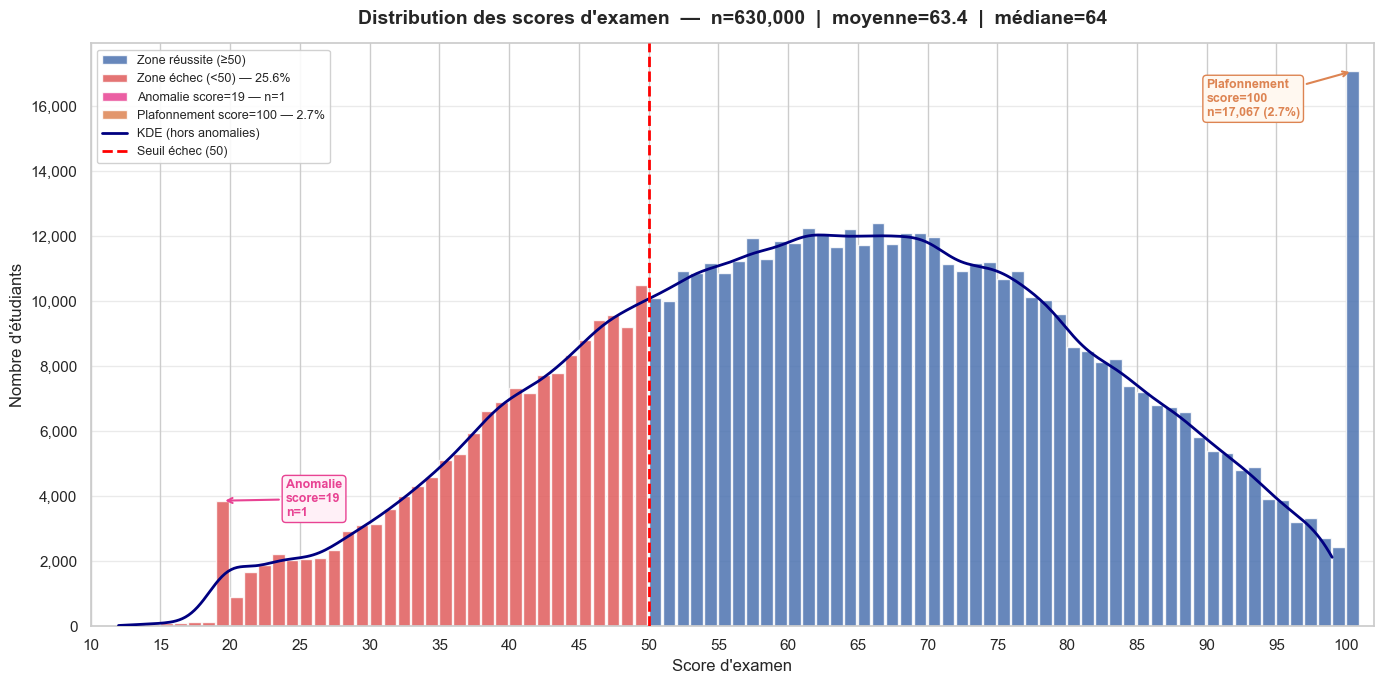

In [18]:
s = df['score_examen']
n_total = len(s)
n_100   = (s == 100).sum()
n_fail  = (s < 50).sum()
n_19    = (s == 19).sum()

counts, edges = np.histogram(s, bins=np.arange(12, 102, 1))

fig1, ax1 = plt.subplots(figsize=(14, 7))

bar_colors = []
for left, right in zip(edges[:-1], edges[1:]):
    mid = (left + right) / 2
    if mid == 19:    bar_colors.append('#E84393')
    elif mid == 100: bar_colors.append('#DD8452')
    elif mid < 50:   bar_colors.append('#E05C5C')
    else:            bar_colors.append('#4C72B0')

ax1.bar(edges[:-1], counts, width=0.9, color=bar_colors, alpha=0.85, align='edge', zorder=2)

s_kde = s[(s != 100) & (s != 19)]
kde = gaussian_kde(s_kde, bw_method=0.08)
x_kde = np.linspace(12, 99, 400)
kde_vals = kde(x_kde) * len(s_kde)
ax1.plot(x_kde, kde_vals, color='navy', linewidth=2.0, label='KDE (hors anomalies)', zorder=3)

ax1.axvline(50, color='red', linestyle='--', linewidth=2,
            label=f'Seuil échec 50 — {n_fail:,} étudiants ({n_fail/n_total:.1%})', zorder=4)

idx_19 = np.where(edges[:-1] == 19)[0]
if len(idx_19):
    h19 = counts[idx_19[0]]
    ax1.annotate(
        f'Anomalie\nscore=19\nn={n_19:,}',
        xy=(19.45, h19), xytext=(24, h19 * 0.88),
        fontsize=9, color='#E84393', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='#E84393', lw=1.5),
        bbox=dict(boxstyle='round,pad=0.3', fc='#fff0f7', ec='#E84393', lw=1)
    )

ax1.annotate(
    f'Plafonnement\nscore=100\nn={n_100:,} ({n_100/n_total:.1%})',
    xy=(100.45, n_100), xytext=(90, n_100 * 0.92),
    fontsize=9, color='#DD8452', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#DD8452', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', fc='#fff8f0', ec='#DD8452', lw=1)
)

legend_elements = [
    mpatches.Patch(facecolor='#4C72B0', alpha=0.85, label='Zone réussite (≥50)'),
    mpatches.Patch(facecolor='#E05C5C', alpha=0.85, label=f'Zone échec (<50) — {n_fail/n_total:.1%}'),
    mpatches.Patch(facecolor='#E84393', alpha=0.85, label=f'Anomalie score=19 — n={n_19:,}'),
    mpatches.Patch(facecolor='#DD8452', alpha=0.85, label=f'Plafonnement score=100 — {n_100/n_total:.1%}'),
    plt.Line2D([0], [0], color='navy', linewidth=2, label='KDE (hors anomalies)'),
    plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='Seuil échec (50)'),
]
ax1.legend(handles=legend_elements, loc='upper left', fontsize=9, framealpha=0.9)
ax1.set_title(
    f"Distribution des scores d'examen  —  n={n_total:,}"
    f'  |  moyenne={s.mean():.1f}  |  médiane={s.median():.0f}',
    fontsize=14, fontweight='bold', pad=14
)
ax1.set_xlabel("Score d'examen", fontsize=12)
ax1.set_ylabel("Nombre d'étudiants", fontsize=12)
ax1.set_xlim(10, 102)
ax1.set_xticks(range(10, 101, 5))
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.grid(axis='y', alpha=0.4, zorder=0)
plt.tight_layout()
plt.show()

### Graphe 3 — Distribution du score selon les variables catégorielles

Les **boîtes à moustaches** (*box plots*) montrent la distribution du score pour chaque modalité d'une variable catégorielle :
- **Boîte** : contient 50 % des données (du 25e au 75e percentile — *IQR : InterQuartile Range*).
- **Ligne centrale** : médiane (valeur du milieu).
- **Moustaches** : étendue des valeurs hors de la boîte (hors *outliers*).

Les modalités sont **triées par médiane croissante** : si les médianes diffèrent significativement entre modalités, la variable est **discriminante** — elle aide le modèle à prédire l'échec. La ligne rouge indique le seuil d'échec (score = 50).

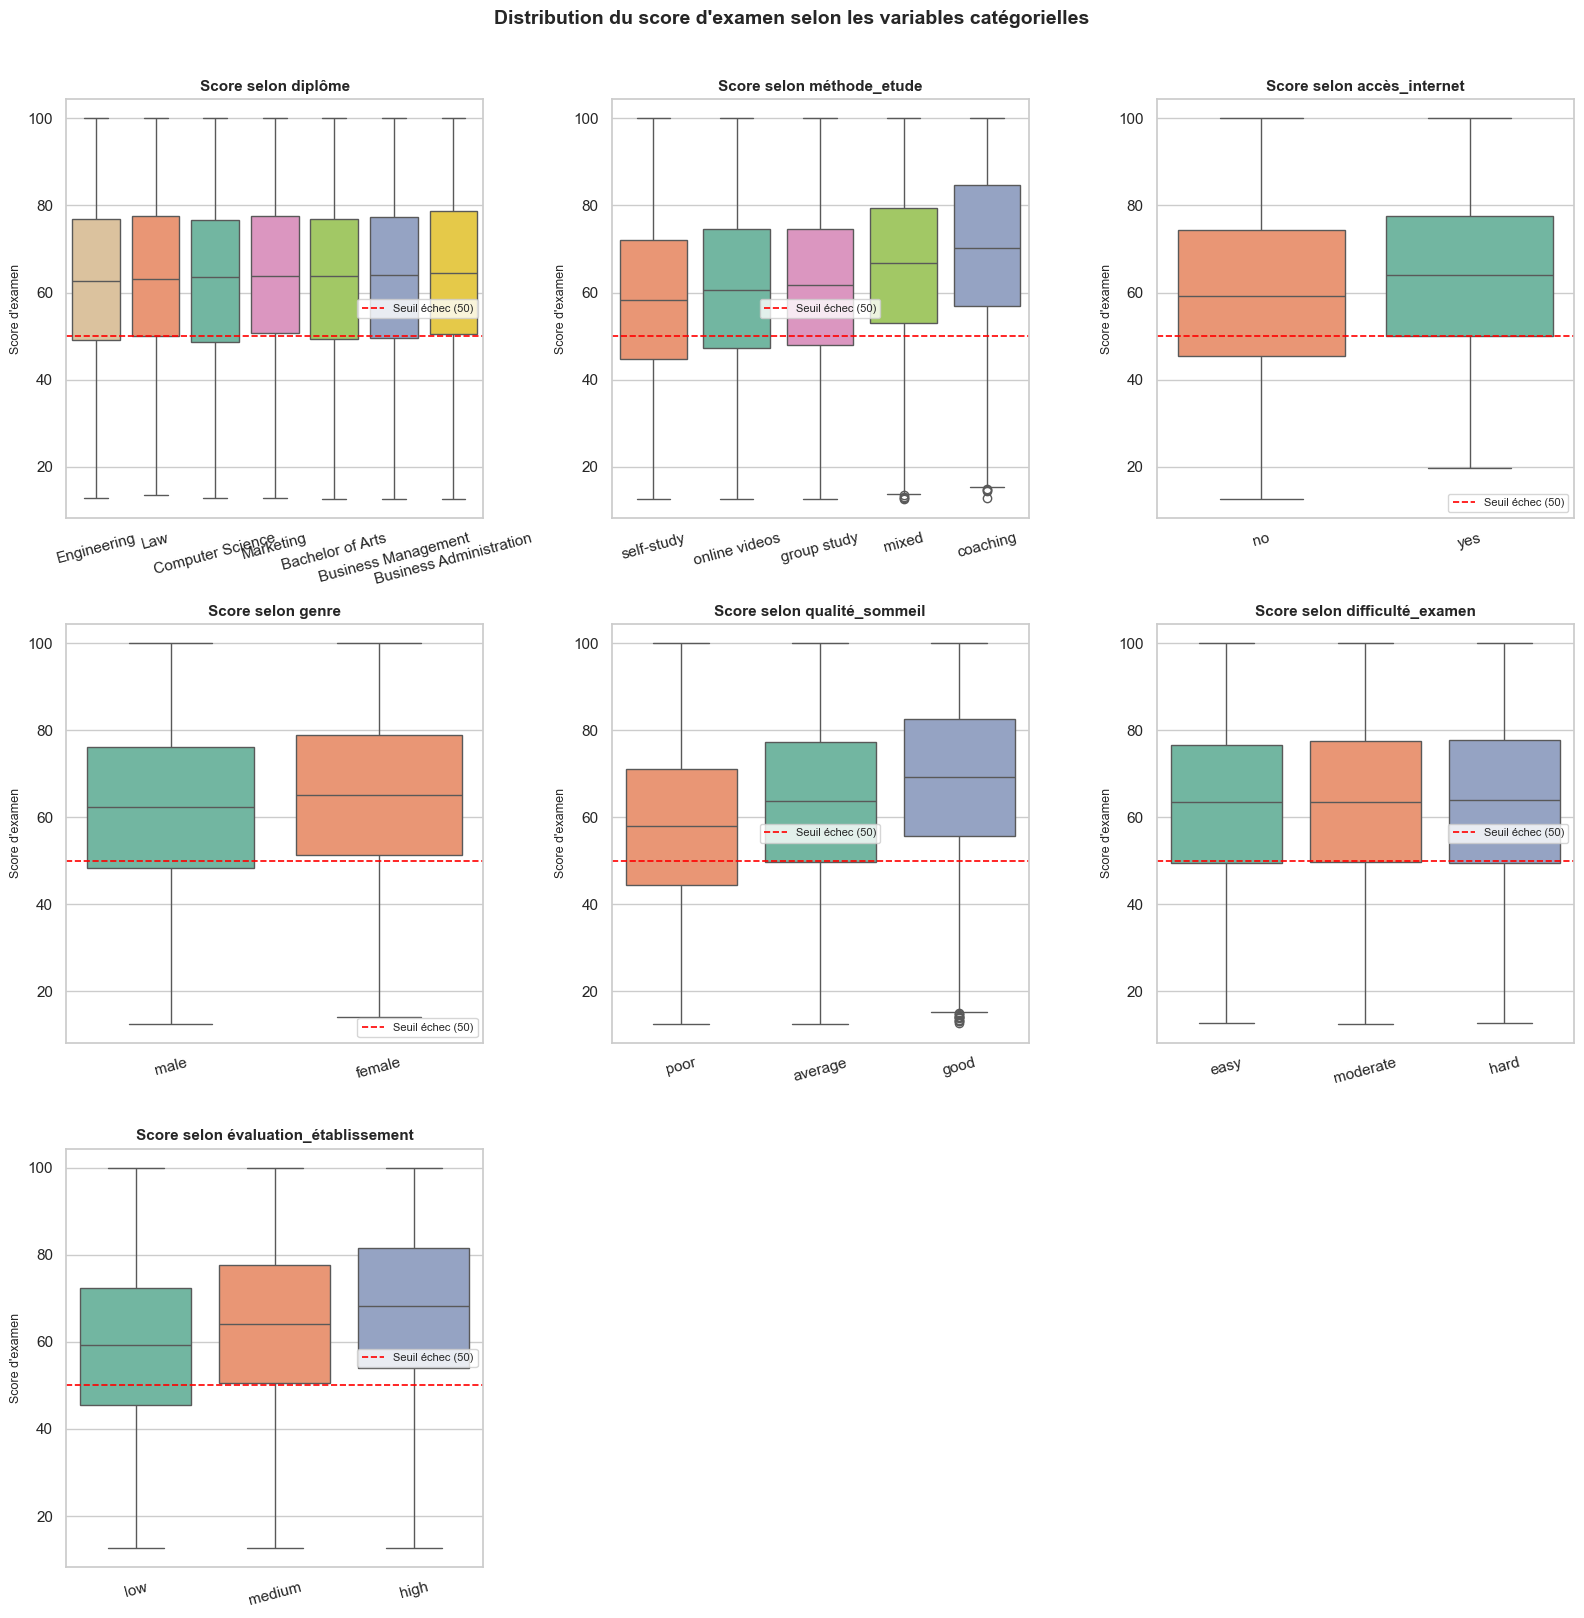

In [19]:
cat_cols = [
    'diplôme', 'méthode_etude', 'accès_internet', 'genre',
    'qualité_sommeil', 'difficulté_examen', 'évaluation_établissement'
]
fig3, axes3 = plt.subplots(3, 3, figsize=(16, 16))

for ax, col in zip(axes3.flat, cat_cols):
    order = df.groupby(col)['score_examen'].median().sort_values().index
    sns.boxplot(data=df, x=col, y='score_examen',
                order=order, ax=ax, hue=col, palette='Set2', legend=False)
    ax.axhline(50, color='red', linestyle='--', linewidth=1.2, label='Seuil échec (50)')
    ax.set_title(f'Score selon {col}', fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel("Score d'examen", fontsize=9)
    ax.tick_params(axis='x', rotation=15)
    ax.legend(fontsize=8)

for j in range(len(cat_cols), len(axes3.flat)): # hide empty graph place
    axes3.flat[j].axis('off')

fig3.suptitle(
    "Distribution du score d'examen selon les variables catégorielles",
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

### Graphe 4 — Matrice de corrélation (Spearman)

Mesure la **dépendance monotone** entre chaque paire de variables.

**Corrélation de Spearman** (choisie ici plutôt que Pearson) : mesure si la relation entre deux variables est *monotone* — l'une augmente quand l'autre augmente, sans forcément être linéaire. Elle est mieux adaptée aux **variables ordinales** et aux **distributions non-normales**.

- Valeur proche de **+1** : forte corrélation positive.
- Valeur proche de **−1** : forte corrélation négative.
- Valeur proche de **0** : peu ou pas de lien.

Deux modes disponibles via `corr_mode` :
- `'compact'` : variables originales (13 colonnes) — lisibilité maximale.
- `'expanded'` : toutes les colonnes après encodage OHE (27 colonnes) — précision maximale.

Le triangle supérieur est masqué (*mask*) car la matrice est **symétrique** — chaque paire n'apparaît qu'une fois.

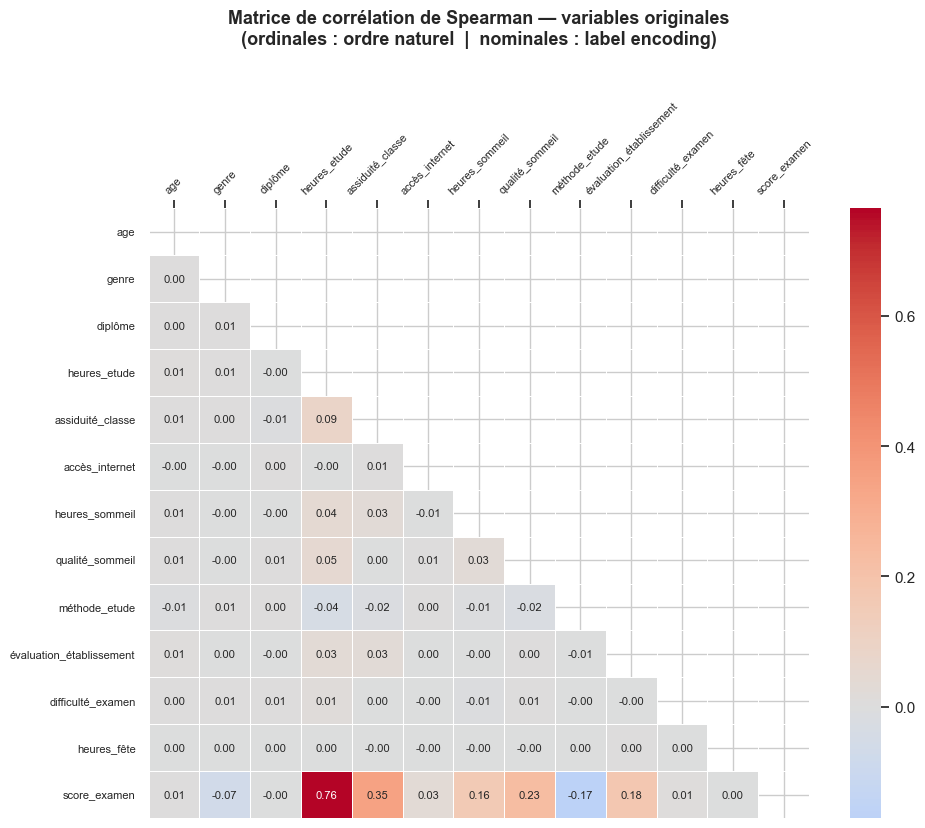

In [20]:
from sklearn.preprocessing import LabelEncoder

# Choisir le mode d'affichage de la matrice de corrélation :
#   'compact'  → variables originales (13 colonnes), corrélation Spearman
#   'expanded' → toutes les colonnes après encodage OHE (27 colonnes), corrélation Pearson
corr_mode = 'compact'

if corr_mode == 'compact':
    df_corr = X_train_orig.copy()
    df_corr['score_examen'] = y_train.values

    # Ordinales : ordre naturel préservé
    for col, mapping in {
        'qualité_sommeil':          {'poor': 0, 'average': 1, 'good': 2},
        'évaluation_établissement': {'low':  0, 'medium':  1, 'high': 2},
        'difficulté_examen':        {'easy': 0, 'moderate': 1, 'hard': 2},
    }.items():
        df_corr[col] = df_corr[col].map(mapping)

    # Nominales : label encoding (1 seule colonne par variable)
    le = LabelEncoder()
    for col in ['genre', 'diplôme', 'accès_internet', 'méthode_etude']:
        df_corr[col] = le.fit_transform(df_corr[col].astype(str))

    corr_matrix = df_corr.corr(method='spearman')
    title = 'Matrice de corrélation de Spearman — variables originales\n(ordinales : ordre naturel  |  nominales : label encoding)'

else:  # 'expanded'
    df_corr = pd.DataFrame(X_train_dense, columns=feat_names_base)
    df_corr['score_examen'] = y_train.values
    corr_matrix = df_corr.corr(method='pearson')
    title = 'Matrice de corrélation de Pearson — toutes les colonnes après encodage OHE'

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

n_feats  = len(df_corr.columns)
fig_w    = max(10, n_feats * 0.75)
fig_h    = max(8,  n_feats * 0.65)
annot_sz = max(6, 11 - n_feats // 4)

fig4, ax4 = plt.subplots(figsize=(fig_w, fig_h))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.4, ax=ax4,
    annot_kws={'size': annot_sz}
)
ax4.xaxis.tick_top()
ax4.xaxis.set_label_position('top')
ax4.set_title(title, fontsize=13, fontweight='bold', pad=40)
ax4.tick_params(axis='x', rotation=45, labelsize=annot_sz)
ax4.tick_params(axis='y', labelsize=annot_sz)
plt.tight_layout()
plt.show()

### Graphe 5 — Importance des features (Mutual Information — MI)

La **Mutual Information** mesure la **dépendance statistique** entre chaque feature et la variable cible **continue** `score_examen`.

Contrairement à la corrélation de Spearman, la MI **capture aussi les relations non-linéaires** — une feature peut être très informative sans être monotonement corrélée à la cible.

- **Score MI = 0** : la feature est indépendante de la cible → inutile pour le modèle.
- **Score MI élevé** : la feature apporte beaucoup d'information sur le score.

> **Encodage utilisé pour la MI** : on garde **une seule colonne par variable** (LabelEncoder pour les nominales, mapping ordinal pour les ordinales) plutôt que du One-Hot. Cela permet d'obtenir directement un score MI par variable originale, sans étape d'agrégation.
>
> Les variables discrètes (binaires, ordinales et nominales encodées) sont signalées via `discrete_features=...` pour que `mutual_info_regression` utilise l'estimateur k-NN approprié (et non l'estimateur continu, qui biaiserait le score).

Échantillonnage : 50,000 / 378,000 lignes (13%) pour accélérer le calcul MI...
Calcul Mutual Information (12 features, 50,000 lignes)...
Calcul MI terminé.


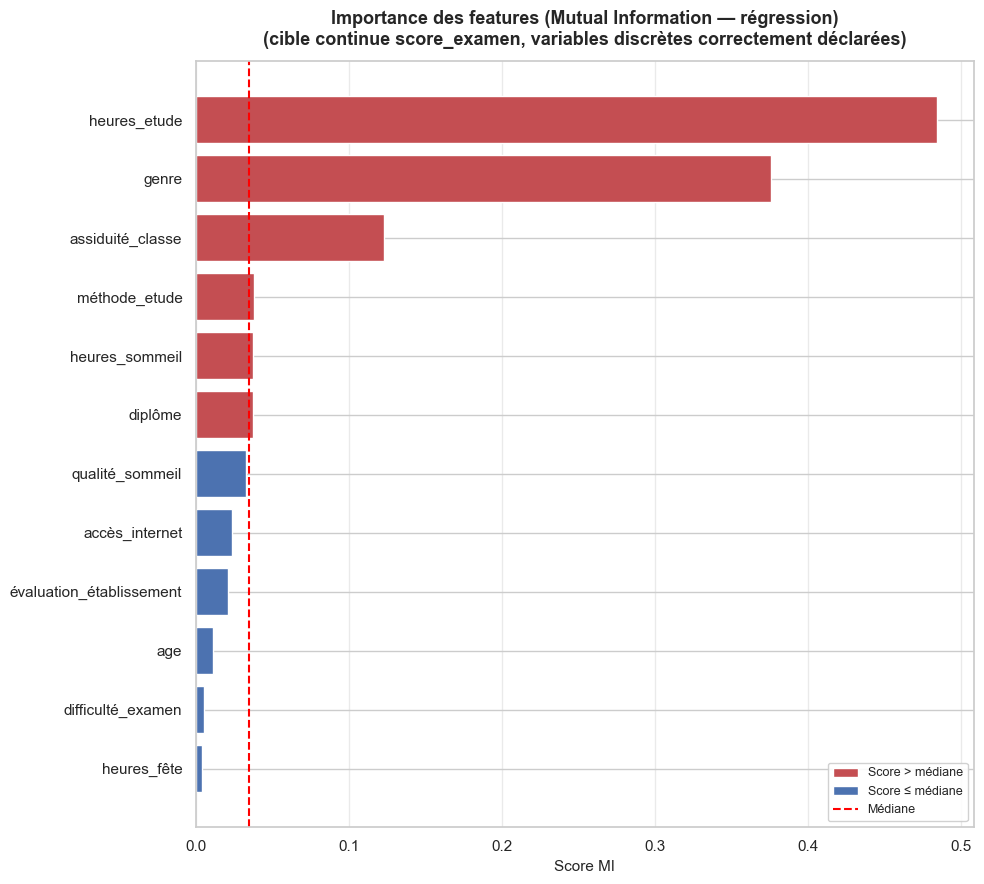

In [21]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder

# Travailler sur les variables ORIGINALES (pas sur la sortie du ColumnTransformer)
df_mi = X_train_orig.copy()

# Ordinales : ordre naturel
for col, mapping in {
    'qualité_sommeil':          {'poor': 0, 'average': 1, 'good': 2},
    'évaluation_établissement': {'low':  0, 'medium':  1, 'high': 2},
    'difficulté_examen':        {'easy': 0, 'moderate': 1, 'hard': 2},
}.items():
    df_mi[col] = df_mi[col].map(mapping)

# Nominales : label encoding (1 colonne par variable, PAS de OHE pour le MI)
le = LabelEncoder()
for col in ['genre', 'diplôme', 'accès_internet', 'méthode_etude']:
    df_mi[col] = le.fit_transform(df_mi[col].astype(str))

# Imputation propre (médiane), surtout PAS fillna(0)
df_mi = df_mi.fillna(df_mi.median(numeric_only=True))

# Échantillonnage pour la rapidité
n_rows = len(df_mi)
if n_rows > MI_SAMPLE_SIZE:
    print(f'Échantillonnage : {MI_SAMPLE_SIZE:,} / {n_rows:,} lignes '
          f'({MI_SAMPLE_SIZE/n_rows:.0%}) pour accélérer le calcul MI...')
    sample_idx = df_mi.sample(MI_SAMPLE_SIZE, random_state=42).index
    X_mi_sample = df_mi.loc[sample_idx]
    y_mi_sample = y_train.loc[sample_idx]
else:
    X_mi_sample = df_mi
    y_mi_sample = y_train

# Marquer les variables non continues comme discrètes (corrige le biais k-NN sur binaires/ordinales)
discrete_cols = ['genre', 'diplôme', 'accès_internet', 'méthode_etude',
                 'qualité_sommeil', 'évaluation_établissement', 'difficulté_examen']
discrete_mask = [c in discrete_cols for c in X_mi_sample.columns]

# CIBLE CONTINUE → mutual_info_regression (et NON mutual_info_classif)
print(f'Calcul Mutual Information ({X_mi_sample.shape[1]} features, {len(X_mi_sample):,} lignes)...')
mi = mutual_info_regression(
    X_mi_sample, y_mi_sample,
    discrete_features=discrete_mask,
    random_state=42, n_neighbors=3
)
mi_series = pd.Series(mi, index=X_mi_sample.columns).sort_values(ascending=True)
print('Calcul MI terminé.')

# ── Graphe ─────────────────────────────────────────────────────
fig5, ax5 = plt.subplots(figsize=(10, 9))
mi_colors = [PALETTE[3] if v > mi_series.median() else PALETTE[0] for v in mi_series.values]
ax5.barh(mi_series.index, mi_series.values, color=mi_colors)
ax5.axvline(mi_series.median(), color='red', linestyle='--', linewidth=1.5)
legend_mi = [
    mpatches.Patch(facecolor=PALETTE[3], label='Score > médiane'),
    mpatches.Patch(facecolor=PALETTE[0], label='Score ≤ médiane'),
    plt.Line2D([0], [0], color='red', linestyle='--', linewidth=1.5, label='Médiane'),
]
ax5.legend(handles=legend_mi, fontsize=9, framealpha=0.9)
ax5.set_title(
    'Importance des features (Mutual Information — régression)\n'
    '(cible continue score_examen, variables discrètes correctement déclarées)',
    fontsize=13, fontweight='bold', pad=12
)
ax5.set_xlabel('Score MI', fontsize=11)
ax5.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

=== Statistiques par genre ===


C:\Users\Admin\AppData\Local\Temp\ipykernel_19012\3800081591.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats = X_train_orig.groupby('genre').apply(


               n       mean  median        std    min    max    p_fail
genre                                                                 
female  158592.0  65.003103   65.13  18.745031  14.11  100.0  0.228801
male    219408.0  62.232852   62.40  18.993153  12.60  100.0  0.275295


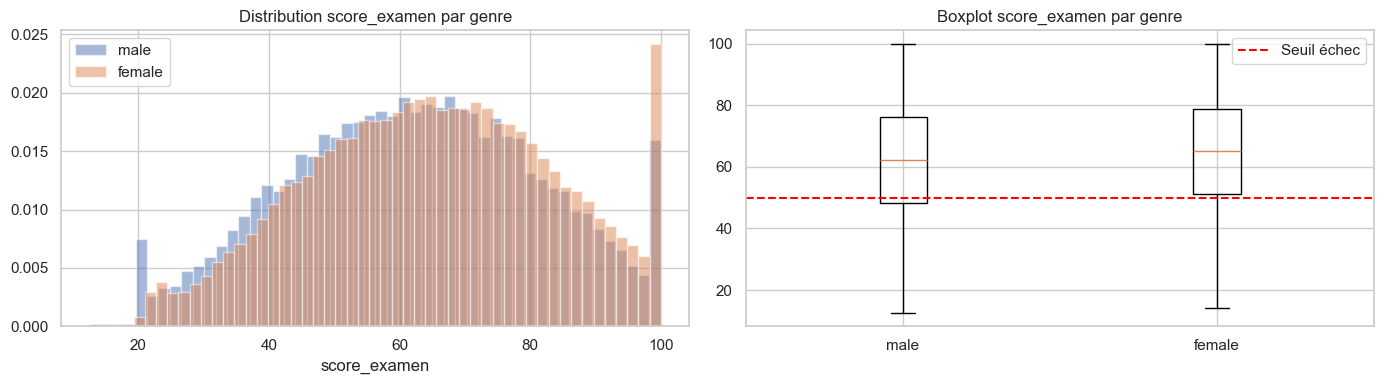

In [22]:
# Diagnostic genre vs score_examen
print("=== Statistiques par genre ===")
stats = X_train_orig.groupby('genre').apply(
    lambda g: pd.Series({
        'n':       len(g),
        'mean':    y_train.loc[g.index].mean(),
        'median':  y_train.loc[g.index].median(),
        'std':     y_train.loc[g.index].std(),
        'min':     y_train.loc[g.index].min(),
        'max':     y_train.loc[g.index].max(),
        'p_fail':  (y_train.loc[g.index] < 50).mean(),
    })
)
print(stats)

# Distribution visuelle
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogrammes superposés
for g, color in zip(['male', 'female'], ['#4C72B0', '#DD8452']):
    mask = X_train_orig['genre'] == g
    axes[0].hist(y_train[mask], bins=50, alpha=0.5, label=g, color=color, density=True)
axes[0].set_title('Distribution score_examen par genre')
axes[0].set_xlabel('score_examen'); axes[0].legend()

# Boxplot
data_box = [y_train[X_train_orig['genre'] == g] for g in ['male', 'female']]
axes[1].boxplot(data_box, tick_labels=['male', 'female'])
axes[1].axhline(50, color='red', linestyle='--', label='Seuil échec')
axes[1].set_title('Boxplot score_examen par genre')
axes[1].legend()

plt.tight_layout(); plt.show()

## 6. Résultats et visualisations des modèles

Les graphes suivants résument les performances de chaque modèle et analysent leur comportement d'apprentissage. Ils permettent de choisir le meilleur modèle et de détecter d'éventuels problèmes de **sur-apprentissage** (*overfitting* — le modèle mémorise le train set au lieu de généraliser) ou de **sous-apprentissage** (*underfitting* — le modèle est trop simple).

### Graphe 6 — Comparaison des modèles (MAE sur validation set)

Visualise le **MAE** de chaque modèle sur le validation set. La barre mise en valeur (orange) correspond au modèle avec le **MAE le plus bas** (meilleur modèle). La ligne rouge représente le MAE de la **baseline** — tout modèle en dessous apporte une valeur ajoutée réelle par rapport à une prédiction naïve.

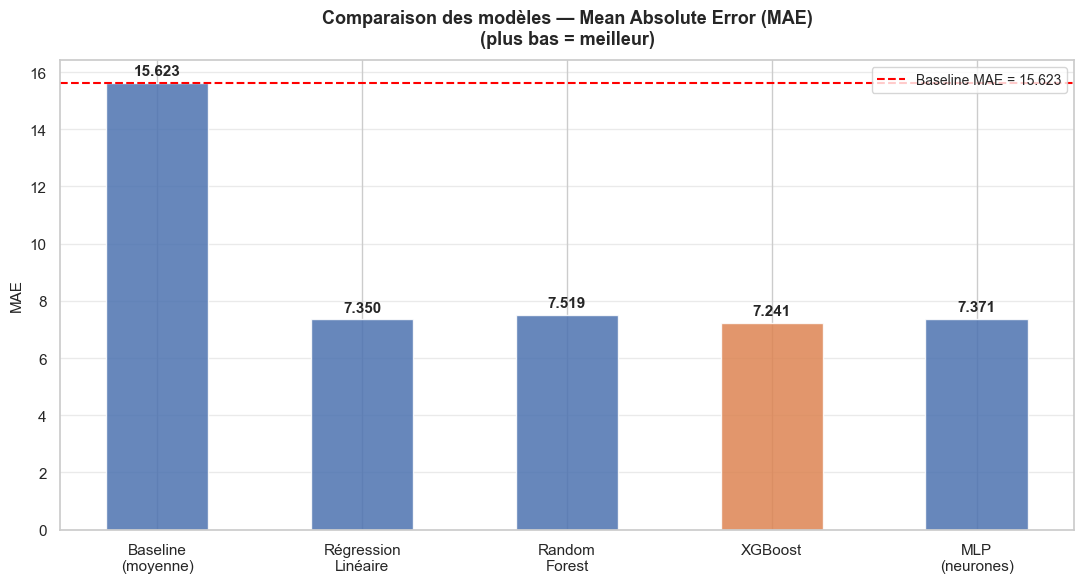

In [23]:
model_names = [
    'Baseline\n(moyenne)',
    'Régression\nLinéaire',
    'Random\nForest',
    'XGBoost',
    'MLP\n(neurones)'
]
model_maes = [mae_baseline, mae_lr, mae_rf, mae_xgb, mae_mlp]

best_idx  = int(np.argmin(model_maes))
bar_cols6 = [PALETTE[1] if i == best_idx else PALETTE[0] for i in range(len(model_maes))]

fig6, ax6 = plt.subplots(figsize=(11, 6))
bars6 = ax6.bar(model_names, model_maes, color=bar_cols6, alpha=0.85, width=0.5)

for bar, mae in zip(bars6, model_maes):
    ax6.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(model_maes) * 0.01,
        f'{mae:.3f}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax6.axhline(mae_baseline, color='red', linestyle='--', linewidth=1.5,
            label=f'Baseline MAE = {mae_baseline:.3f}')
ax6.set_title(
    'Comparaison des modèles — Mean Absolute Error (MAE)\n(plus bas = meilleur)',
    fontsize=13, fontweight='bold', pad=12
)
ax6.set_ylabel('MAE', fontsize=11)
ax6.legend(fontsize=10)
ax6.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

### Graphe 7 — Courbe d'apprentissage XGBoost (RMSE vs rounds)

Visualise la convergence du modèle XGBoost au fil des **rounds de boosting**.

- **RMSE** (*Root Mean Squared Error* — racine de l'erreur quadratique moyenne) : pénalise davantage les grandes erreurs que le MAE. Utilisé ici car c'est la métrique surveillée par l'*early stopping*.
- Une courbe qui **descend puis se stabilise** indique une bonne convergence sans sur-apprentissage.
- Le **meilleur round** (RMSE minimal sur le validation set) est marqué d'un point rouge — c'est là que l'*early stopping* a arrêté l'entraînement pour éviter l'overfitting.

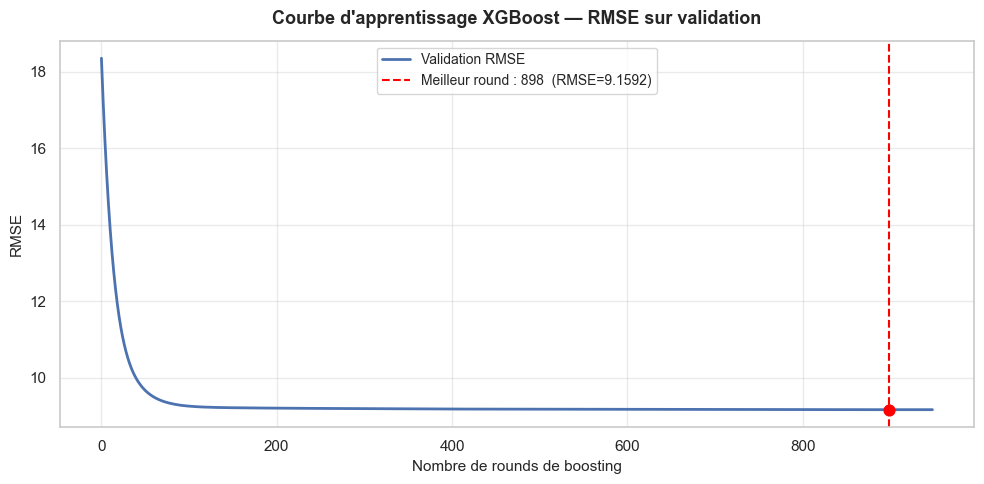

In [24]:
results = model_xgb.evals_result()
epochs  = len(results['validation_0']['rmse'])

fig7, ax7 = plt.subplots(figsize=(10, 5))
ax7.plot(range(epochs), results['validation_0']['rmse'],
         color=PALETTE[0], linewidth=2, label='Validation RMSE')

best_round = int(np.argmin(results['validation_0']['rmse']))
best_rmse  = results['validation_0']['rmse'][best_round]
ax7.axvline(best_round, color='red', linestyle='--', linewidth=1.5,
            label=f'Meilleur round : {best_round}  (RMSE={best_rmse:.4f})')
ax7.scatter([best_round], [best_rmse], color='red', zorder=5, s=60)
ax7.set_xlabel('Nombre de rounds de boosting', fontsize=11)
ax7.set_ylabel('RMSE', fontsize=11)
ax7.set_title("Courbe d'apprentissage XGBoost — RMSE sur validation",
              fontsize=13, fontweight='bold', pad=12)
ax7.legend(fontsize=10)
ax7.grid(alpha=0.4)
plt.tight_layout()
plt.show()

### Graphe 8 — Importance des features XGBoost (gain)

Mesure la contribution de chaque feature aux décisions du modèle XGBoost via le **gain** : amélioration moyenne de la qualité des *splits* chaque fois que la feature est utilisée dans un arbre.

- Un **gain élevé** = la feature aide beaucoup à réduire l'erreur à chaque division de l'arbre.
- Ce graphe **complète la MI** (Graphe 5, calculée avant l'entraînement) : l'importance XGBoost est mesurée **après** l'entraînement, en fonction de ce que le modèle a réellement appris.

> **Agrégation OHE** : pour les variables nominales encodées en *One-Hot*, on prend le **maximum** des importances parmi les colonnes d'une même variable originale (cohérent avec l'agrégation utilisée pour la MI au Graphe 5). Sommer les importances surévaluerait artificiellement les variables comportant beaucoup de modalités.

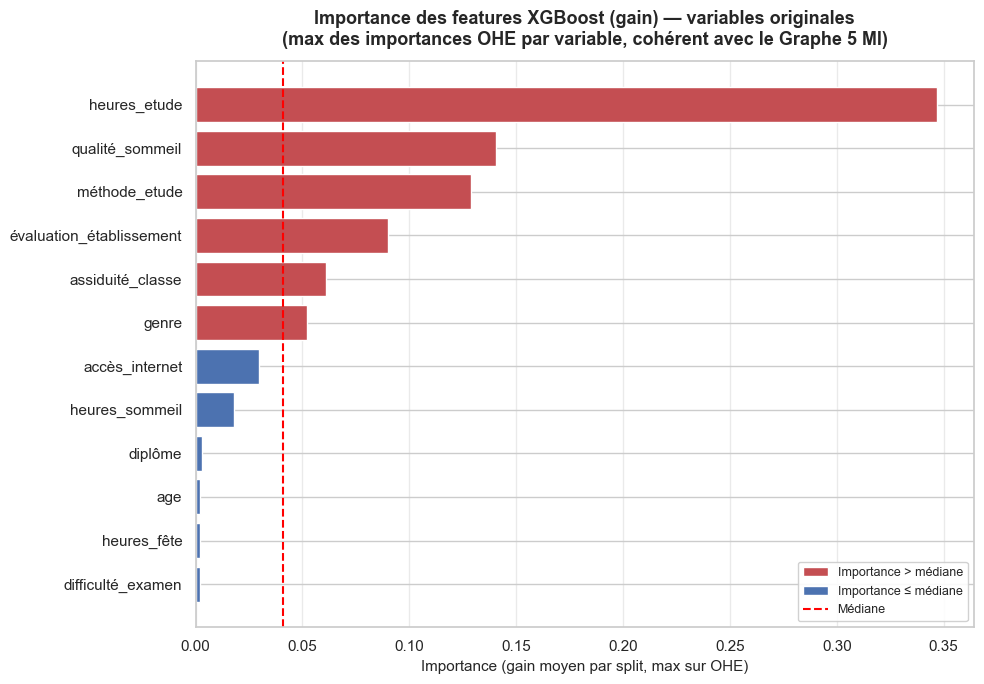

In [25]:
one_hot_cols_g8 = ['genre', 'diplôme', 'accès_internet', 'méthode_etude']

def _orig_name_g8(feat):
    for col in one_hot_cols_g8:
        if feat.startswith(col + '_'):
            return col
    return feat

fi_vals = model_xgb.feature_importances_
fi_raw  = pd.Series(fi_vals, index=feat_names_base)

# Agrégation par MAX (cohérent avec le Graphe 5 MI qui prend aussi le max)
# Sommer surévaluerait les variables avec beaucoup de modalités
fi_orig = (fi_raw.groupby(fi_raw.index.map(_orig_name_g8))
                  .max()
                  .sort_values(ascending=True))

fig8, ax8 = plt.subplots(figsize=(10, 7))
fi_colors = [PALETTE[3] if v > fi_orig.median() else PALETTE[0] for v in fi_orig.values]
ax8.barh(fi_orig.index, fi_orig.values, color=fi_colors)
ax8.axvline(fi_orig.median(), color='red', linestyle='--', linewidth=1.5, label='Médiane')
legend_fi = [
    mpatches.Patch(facecolor=PALETTE[3], label='Importance > médiane'),
    mpatches.Patch(facecolor=PALETTE[0], label='Importance ≤ médiane'),
    plt.Line2D([0], [0], color='red', linestyle='--', linewidth=1.5, label='Médiane'),
]
ax8.legend(handles=legend_fi, fontsize=9, framealpha=0.9)
ax8.set_title(
    'Importance des features XGBoost (gain) — variables originales\n'
    '(max des importances OHE par variable, cohérent avec le Graphe 5 MI)',
    fontsize=13, fontweight='bold', pad=12
)
ax8.set_xlabel('Importance (gain moyen par split, max sur OHE)', fontsize=11)
ax8.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()